# Qwen 2.5 72B on 2 GPUs

Notebook optimisé pour `Qwen/Qwen2.5-72B-Instruct` sur **2 GPUs**.

Objectifs:
- variables de configuration séparées et faciles à modifier
- vérification GPU / mémoire après chargement du modèle
- smoke test sur 20 lignes
- mesure du débit (`rows/s`) et du parsing
- indicateur simple de convergence / stabilité
- run complet exportable
- sanity check final
- graphiques de comparaison multi-modèles si plusieurs CSV existent déjà


## 1) Imports

In [1]:
import os
import gc
import json
import math
import re
import shutil
import subprocess
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from vllm import LLM, SamplingParams


/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 2) Runtime and GPU configuration

In [2]:
# GPU visibility: set exactly the two GPUs you want to use.
CUDA_VISIBLE_DEVICES = "1,2"
TENSOR_PARALLEL_SIZE = 2

os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES
os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = "1"
os.environ["MKL_THREADING_LAYER"] = "GNU"
os.environ["MKL_SERVICE_FORCE_INTEL"] = "1"

conda_prefix = os.environ.get("CONDA_PREFIX", "")
if conda_prefix:
    conda_lib = f"{conda_prefix}/lib"
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]
    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = f"{conda_lib}:{ld_library_path}" if ld_library_path else conda_lib

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("TENSOR_PARALLEL_SIZE:", TENSOR_PARALLEL_SIZE)


CUDA_VISIBLE_DEVICES: 1,2
TENSOR_PARALLEL_SIZE: 2


## 3) Paths

In [3]:
from pathlib import Path

# Fixed base path for this machine
PROJECT_ROOT = Path("/home/cbenavent/test/Arcom_rares")

# Dataset in /data
DATASET_PATH = PROJECT_ROOT / "data" / "annotation_working_master_human_2100_seed.csv"

# Output and plots
OUTPUT_ROOT = PROJECT_ROOT / "communication_function_outputs" / "qwen72b_2gpu"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

LATEX_DIR = PROJECT_ROOT / "latex"
LATEX_DIR.mkdir(parents=True, exist_ok=True)

# Safety check
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET_PATH}")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_PATH:", DATASET_PATH)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("LATEX_DIR:", LATEX_DIR)


PROJECT_ROOT: /home/cbenavent/test/Arcom_rares
DATASET_PATH: /home/cbenavent/test/Arcom_rares/data/annotation_working_master_human_2100_seed.csv
OUTPUT_ROOT: /home/cbenavent/test/Arcom_rares/communication_function_outputs/qwen72b_2gpu
LATEX_DIR: /home/cbenavent/test/Arcom_rares/latex


## 4) Model configuration

In [4]:
MODEL_NAME = "Qwen/Qwen2.5-72B-Instruct"
CHAT_MODE = "hf_auto"
MODEL_SLUG = "qwen_qwen2_5_72b_instruct"

# Generation
TEMPERATURE = 0.0
MAX_NEW_TOKENS = 220

# Memory / context
VLLM_GPU_MEMORY_UTILIZATION = 0.90
MAX_MODEL_LEN = 8192
VLLM_SWAP_SPACE_GB = 16
MODEL_DTYPE = "bfloat16"
DISABLE_CUSTOM_ALL_REDUCE = False

# Execution
SMOKE_TEST_N = 20
FULL_RUN_N = None   # None = all available rows
PROMPT_BATCH_LABEL = "qwen72b_2gpu_v1"

MODEL_KWARGS: dict[str, Any] = {
    "tensor_parallel_size": TENSOR_PARALLEL_SIZE,
    "trust_remote_code": True,
    "gpu_memory_utilization": VLLM_GPU_MEMORY_UTILIZATION,
    "dtype": MODEL_DTYPE,
    "max_model_len": int(MAX_MODEL_LEN),
}
if DISABLE_CUSTOM_ALL_REDUCE:
    MODEL_KWARGS["disable_custom_all_reduce"] = True

print("MODEL_NAME:", MODEL_NAME)
print("CHAT_MODE:", CHAT_MODE)
print("MAX_NEW_TOKENS:", MAX_NEW_TOKENS)
print("MAX_MODEL_LEN:", MAX_MODEL_LEN)
print("VLLM_GPU_MEMORY_UTILIZATION:", VLLM_GPU_MEMORY_UTILIZATION)


MODEL_NAME: Qwen/Qwen2.5-72B-Instruct
CHAT_MODE: hf_auto
MAX_NEW_TOKENS: 220
MAX_MODEL_LEN: 8192
VLLM_GPU_MEMORY_UTILIZATION: 0.9


## 5) Input strategy

In [5]:
# Choose one:
# - "visual_only"
# - "all_french_columns"
# - "long_french_text_only"

COLUMN_STRATEGY = "all_french_columns"
MIN_TOKENS_PER_FIELD = 7
TEXT_COLUMNS_FR = ["Script", "Incrustation", "Titre", "Visuel"]

def clean_text(value) -> str:
    text = "" if pd.isna(value) else str(value)
    text = text.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def token_count(text: str) -> int:
    return 0 if not text else len(text.split())

def join_labeled_parts(parts: list[tuple[str, str]]) -> str:
    kept = []
    for label, text in parts:
        text = clean_text(text)
        if text:
            kept.append(f"{label}: {text}")
    return "\n".join(kept).strip()

def build_input_text(row: pd.Series) -> str:
    fr_parts = [(col, row.get(col, "")) for col in TEXT_COLUMNS_FR]
    if COLUMN_STRATEGY == "visual_only":
        return clean_text(row.get("Visuel", ""))
    if COLUMN_STRATEGY == "all_french_columns":
        return join_labeled_parts(fr_parts)
    if COLUMN_STRATEGY == "long_french_text_only":
        selected = []
        for col in TEXT_COLUMNS_FR:
            text = clean_text(row.get(col, ""))
            if token_count(text) > MIN_TOKENS_PER_FIELD:
                selected.append((col, text))
        return join_labeled_parts(selected)
    raise ValueError(f"Unknown COLUMN_STRATEGY: {COLUMN_STRATEGY}")


## 6) Prompt and parser

In [6]:
RUBRIC_TEXT = '''You score French automotive ads on 3 dimensions from 1 to 5.

- informativeness: factual, technical, concrete product information, offer details, equipment, performance specs, financing or practical product information.
- expressiveness: emotion, desire, identity, style, seduction, aspiration, strong aesthetic or affective framing.
- phatic: social bond, relational tone, conversational closeness, bonding language, direct relationship-maintaining communication.

Rules:
- Score each dimension independently from 1 to 5.
- Use mixed for dominant_dimension only if the highest score is tied.
- dominant_dimension_score must equal the highest score.
- Keep the reason very short and concrete.
- Return strict JSON only.
'''

DIMENSIONS = ["informativeness", "expressiveness", "phatic"]
SCORE_MIN = 1
SCORE_MAX = 5

def output_schema_text() -> str:
    return '''{
  "informativeness": 1,
  "expressiveness": 1,
  "phatic": 1,
  "dominant_dimension": "informativeness|expressiveness|phatic|mixed",
  "dominant_dimension_score": 1,
  "confidence": 0.0,
  "reason": "short explanation"
}'''

def build_prompt_content(ad_text: str) -> str:
    clean_ad_text = " ".join(str(ad_text).split()).strip()
    return (
        f"{RUBRIC_TEXT}\n\n"
        f"Return strict JSON only with:\n{output_schema_text()}\n\n"
        f"Ad to score:\n{clean_ad_text}\n\n"
        "Return only strict JSON."
    )

def render_prompt_for_model(content: str, llm=None) -> str:
    if CHAT_MODE == "plain" or llm is None:
        return content
    tokenizer = llm.get_tokenizer()
    messages = [{"role": "user", "content": content}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def build_prompt(ad_text: str, llm=None) -> str:
    return render_prompt_for_model(build_prompt_content(ad_text), llm=llm)

def clamp_score(value, default=1):
    try:
        score = int(round(float(value)))
    except Exception:
        score = default
    return max(SCORE_MIN, min(SCORE_MAX, score))

def normalize_dimension_name(value):
    text = str(value or "").strip().lower()
    aliases = {
        "informative": "informativeness",
        "information": "informativeness",
        "referential": "informativeness",
        "expressive": "expressiveness",
        "emotive": "expressiveness",
        "emotion": "expressiveness",
        "phatique": "phatic",
    }
    text = aliases.get(text, text)
    return text if text in DIMENSIONS or text == "mixed" else ""

def extract_json_object(text: str) -> dict:
    fenced = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, flags=re.DOTALL)
    candidates = [fenced.group(1)] if fenced else []
    candidates.append(text)
    decoder = json.JSONDecoder()
    for candidate in candidates:
        for match in re.finditer(r"\{", candidate):
            try:
                payload, _ = decoder.raw_decode(candidate[match.start():].strip())
                if isinstance(payload, dict):
                    return payload
            except json.JSONDecodeError:
                continue
    raise ValueError("Could not extract JSON from model output.")

def parse_model_prediction(raw_text: str):
    try:
        payload = extract_json_object(raw_text)
        scores = {
            "informativeness": clamp_score(payload.get("informativeness", 1)),
            "expressiveness": clamp_score(payload.get("expressiveness", 1)),
            "phatic": clamp_score(payload.get("phatic", 1)),
        }
        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        top_score = ranked[0][1]
        top_labels = [k for k, v in ranked if v == top_score]
        dominant_dimension = normalize_dimension_name(payload.get("dominant_dimension")) or ("mixed" if len(top_labels) > 1 else top_labels[0])
        reason = " ".join(str(payload.get("reason", "")).split()).strip() or "strict_json"
        try:
            confidence = round(float(payload.get("confidence", 0.5)), 4)
        except Exception:
            confidence = 0.5
        confidence = max(0.0, min(1.0, confidence))
        return {
            "informativeness": scores["informativeness"],
            "expressiveness": scores["expressiveness"],
            "phatic": scores["phatic"],
            "dominant_dimension": dominant_dimension,
            "dominant_dimension_score": top_score,
            "confidence": confidence,
            "reason": reason,
        }, True, ""
    except Exception as exc:
        return {
            "informativeness": 1,
            "expressiveness": 1,
            "phatic": 1,
            "dominant_dimension": "mixed",
            "dominant_dimension_score": 1,
            "confidence": 0.0,
            "reason": "parse_fallback",
        }, False, str(exc)


## 7) Load data

In [7]:
df = pd.read_csv(DATASET_PATH)
required_cols = ["row_id"] + [c for c in TEXT_COLUMNS_FR if c in df.columns]
sample_df = df.loc[:, required_cols].copy()
sample_df["model_input_text"] = sample_df.apply(build_input_text, axis=1)
sample_df = sample_df[sample_df["model_input_text"].str.strip() != ""].copy()

if FULL_RUN_N is not None:
    sample_df = sample_df.head(FULL_RUN_N).copy()

print("Rows available:", len(sample_df))
display(sample_df[["row_id", "model_input_text"]].head(3))


Rows available: 8938


,row_id,model_input_text
0,0,"Script: L'homme (1) : "" Wou ! (1) ... On va où..."
1,1,"Script: Voix homme : "" 85 000 conducteurs vive..."
2,2,"Script: La femme (1) : "" C'est votre voiture ?..."


## 8) Sampling params and helper boxes

In [8]:
sampling_params = SamplingParams(
    temperature=TEMPERATURE,
    max_tokens=MAX_NEW_TOKENS,
)

def html_box(title: str, body: str, color: str = "#1f4e79", bg: str = "#eef6fb"):
    display(HTML(
        f"""
        <div style="border-left: 6px solid {color}; background:{bg}; padding:10px 14px; margin:8px 0; border-radius:6px;">
            <div style="font-weight:700; margin-bottom:4px;">{title}</div>
            <div style="white-space:pre-wrap;">{body}</div>
        </div>
        """
    ))


## 9) GPU inspection after model load

In [9]:
def inspect_gpu_state():
    try:
        import torch
        rows = []
        if torch.cuda.is_available():
            for i in range(torch.cuda.device_count()):
                free_bytes, total_bytes = torch.cuda.mem_get_info(i)
                used_gb = (total_bytes - free_bytes) / (1024**3)
                total_gb = total_bytes / (1024**3)
                rows.append({
                    "gpu_index": i,
                    "name": torch.cuda.get_device_name(i),
                    "used_gb": round(used_gb, 2),
                    "free_gb": round(free_bytes / (1024**3), 2),
                    "total_gb": round(total_gb, 2),
                    "used_percent": round(used_gb / total_gb * 100, 2),
                })
        gpu_df = pd.DataFrame(rows)
        display(gpu_df)
    except Exception as exc:
        print("Torch GPU inspection failed:", exc)

    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=index,name,memory.used,memory.total,utilization.gpu", "--format=csv,noheader,nounits"],
            capture_output=True,
            text=True,
            check=True,
        )
        print(result.stdout)
    except Exception as exc:
        print("nvidia-smi unavailable:", exc)


## 10) vLLM inference helpers

In [10]:
def run_vllm_batch(sample: pd.DataFrame, show_prompt_preview: bool = True):
    llm = None
    rows = []
    try:
        llm = LLM(model=MODEL_NAME, **MODEL_KWARGS)
        html_box("GPU state after model load", "The table below shows the GPUs currently visible and their memory usage.")
        inspect_gpu_state()

        prompts = [build_prompt(v, llm=llm) for v in sample["model_input_text"].tolist()]
        if show_prompt_preview and prompts:
            print(prompts[0][:700])

        t0 = time.perf_counter()
        try:
            outs = llm.generate(prompts, sampling_params, use_tqdm=True)
        except TypeError:
            outs = llm.generate(prompts, sampling_params)
        t1 = time.perf_counter()

        elapsed = max(0.0, t1 - t0)
        rows_per_sec = len(sample) / elapsed if elapsed > 0 else float("inf")

        for in_row, out in zip(sample.itertuples(index=False), outs):
            raw_text = out.outputs[0].text if out.outputs else ""
            prediction, parse_ok, parse_error = parse_model_prediction(raw_text)
            rows.append({
                "row_id": int(getattr(in_row, "row_id")),
                "model_input_text": getattr(in_row, "model_input_text", ""),
                "model_name": MODEL_NAME,
                "raw_output": raw_text,
                "prediction": prediction,
                "parse_ok": parse_ok,
                "parse_error": parse_error,
            })
        return rows, elapsed, rows_per_sec
    finally:
        try:
            if llm is not None:
                del llm
            gc.collect()
            import torch
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.ipc_collect()
        except Exception:
            pass

def flatten_results(all_results: list[dict]) -> tuple[pd.DataFrame, pd.DataFrame]:
    results_df = pd.DataFrame(all_results)
    scores_df = pd.DataFrame([
        {
            "row_id": item.get("row_id"),
            "model_input_text": item.get("model_input_text", ""),
            "informativeness": (item.get("prediction") or {}).get("informativeness"),
            "expressiveness": (item.get("prediction") or {}).get("expressiveness"),
            "phatic": (item.get("prediction") or {}).get("phatic"),
            "dominant_dimension": (item.get("prediction") or {}).get("dominant_dimension"),
            "confidence": (item.get("prediction") or {}).get("confidence"),
            "model_name": item.get("model_name", ""),
            "parse_ok": item.get("parse_ok", False),
        }
        for item in all_results
    ])
    return results_df, scores_df


## 11) Smoke test on 20 rows

In [11]:
smoke_df = sample_df.head(SMOKE_TEST_N).copy()
html_box("Smoke test", f"Running a small smoke test on {len(smoke_df)} rows before the full corpus run.")

smoke_results, smoke_seconds, smoke_rps = run_vllm_batch(smoke_df, show_prompt_preview=True)
smoke_results_df, smoke_scores_df = flatten_results(smoke_results)

smoke_parse_ok = int(smoke_scores_df["parse_ok"].sum())
smoke_parse_rate = smoke_parse_ok / len(smoke_scores_df) * 100 if len(smoke_scores_df) else 0.0
html_box(
    "Smoke test summary",
    f"Rows: {len(smoke_scores_df)}\nRows/s: {smoke_rps:.2f}\nParse OK: {smoke_parse_ok}/{len(smoke_scores_df)} ({smoke_parse_rate:.1f}%)"
)
display(smoke_scores_df.head(10))


INFO 05-21 12:55:19 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'bfloat16', 'max_model_len': 8192, 'tensor_parallel_size': 2, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-72B-Instruct'}


INFO 05-21 12:55:20 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 05-21 12:55:20 [model.py:1678] Using max model len 8192
INFO 05-21 12:55:20 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=16384.
INFO 05-21 12:55:20 [vllm.py:790] Asynchronous scheduling is enabled.
INFO 05-21 12:55:21 [compilation.py:292] Enabled custom fusions: allreduce_rms


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


WARNING 05-21 12:55:23 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized


/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


...

,gpu_index,name,used_gb,free_gb,total_gb,used_percent
0,0,NVIDIA H100 NVL,87.55,5.54,93.09,94.05
1,1,NVIDIA H100 NVL,87.27,5.82,93.09,93.75


0, NVIDIA H100 NVL, 44841, 95830, 88
1, NVIDIA H100 NVL, 89647, 95830, 2
2, NVIDIA H100 NVL, 89365, 95830, 4
3, NVIDIA H100 NVL, 529, 95830, 0

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
You score French automotive ads on 3 dimensions from 1 to 5.

- informativeness: factual, technical, concrete product information, offer details, equipment, performance specs, financing or practical product information.
- expressiveness: emotion, desire, identity, style, seduction, aspiration, strong aesthetic or affective framing.
- phatic: social bond, relational tone, conversational closeness, bonding language, direct relationship-maintaining communication.

Rules:
- Score each dimension independently from 1 to 5.
- Use mixed for dominant_dimension only if the highest score i


Processed prompts: 100%|██████████| 20/20 [00:04<00:00,  4.25it/s, est. speed input: 2925.97 toks/s, output: 329.81 toks/s]


(EngineCore pid=2382003) INFO 05-21 12:57:06 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=2382003) INFO 05-21 12:57:06 [core.py:1233] Shutdown complete
(Worker_TP1 pid=2382165) INFO 05-21 12:57:06 [multiproc_executor.py:859] WorkerProc shutting down.
(Worker_TP0 pid=2382164) INFO 05-21 12:57:06 [multiproc_executor.py:764] Parent process exited, terminating worker queues
(Worker_TP0 pid=2382164) INFO 05-21 12:57:06 [multiproc_executor.py:859] WorkerProc shutting down.


,row_id,model_input_text,informativeness,expressiveness,phatic,dominant_dimension,confidence,model_name,parse_ok
0,0,"Script: L'homme (1) : "" Wou ! (1) ... On va où...",1,3,3,mixed,0.80,Qwen/Qwen2.5-72B-Instruct,True
1,1,"Script: Voix homme : "" 85 000 conducteurs vive...",4,3,2,informativeness,0.85,Qwen/Qwen2.5-72B-Instruct,True
2,2,"Script: La femme (1) : "" C'est votre voiture ?...",3,4,2,expressiveness,0.85,Qwen/Qwen2.5-72B-Instruct,True
3,3,"Script: La femme (1) : "" C'est votre voiture ?...",4,3,2,informativeness,0.85,Qwen/Qwen2.5-72B-Instruct,True
4,4,"Script: La femme (1) : "" C'est votre voiture ?...",3,4,2,expressiveness,0.85,Qwen/Qwen2.5-72B-Instruct,True
5,5,"Script: Voix homme : "" Pas de montant central,...",4,2,1,informativeness,0.90,Qwen/Qwen2.5-72B-Instruct,True
6,6,"Script: Voix femme (1) : "" Comme la vie serait...",4,3,2,informativeness,0.85,Qwen/Qwen2.5-72B-Instruct,True
7,7,"Script: Voix femme (1) : "" La vie serait plus ...",4,2,2,informativeness,0.85,Qwen/Qwen2.5-72B-Instruct,True
8,8,"Script: Voix homme (1) : "" Le monde de demain ...",4,2,1,informativeness,0.85,Qwen/Qwen2.5-72B-Instruct,True
9,9,"Script: Voix homme (1) : "" Le monde de demain ...",4,2,1,informativeness,0.85,Qwen/Qwen2.5-72B-Instruct,True


## 12) Full run

In [12]:
html_box("Full run", f"Running the full corpus with {len(sample_df)} rows using {MODEL_NAME} on {TENSOR_PARALLEL_SIZE} GPUs.")
full_start_ts = time.perf_counter()
all_results, perf_total_seconds, perf_items_per_second = run_vllm_batch(sample_df, show_prompt_preview=False)
full_end_ts = time.perf_counter()

results_df, scores_df = flatten_results(all_results)

n = len(scores_df)
parse_ok_count = int(scores_df["parse_ok"].sum())
parse_fail_count = n - parse_ok_count
parse_ok_rate = parse_ok_count / n * 100 if n else 0.0

html_box(
    "Full run performance",
    f"Rows: {n}\nTotal seconds: {perf_total_seconds:.2f}\nRows per second: {perf_items_per_second:.2f}\nParse OK rate: {parse_ok_rate:.2f}%"
)


INFO 05-21 12:57:11 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'bfloat16', 'max_model_len': 8192, 'tensor_parallel_size': 2, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-72B-Instruct'}
INFO 05-21 12:57:12 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 05-21 12:57:12 [model.py:1678] Using max model len 8192


/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


(EngineCore pid=2382921) INFO 05-21 12:57:18 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='Qwen/Qwen2.5-72B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-72B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=8192, download_dir=None, load_format=auto, tensor_parallel_size=2, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collect

/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


(Worker pid=2383085) INFO 05-21 12:57:25 [parallel_state.py:1400] world_size=2 rank=0 local_rank=0 distributed_init_method=tcp://127.0.0.1:35011 backend=nccl
(Worker pid=2383086) INFO 05-21 12:57:25 [parallel_state.py:1400] world_size=2 rank=1 local_rank=1 distributed_init_method=tcp://127.0.0.1:35011 backend=nccl


...

(EngineCore pid=2382921) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=2382921) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


,gpu_index,name,used_gb,free_gb,total_gb,used_percent
0,0,NVIDIA H100 NVL,87.55,5.54,93.09,94.05
1,1,NVIDIA H100 NVL,87.27,5.82,93.09,93.75


0, NVIDIA H100 NVL, 44841, 95830, 0
1, NVIDIA H100 NVL, 89647, 95830, 0
2, NVIDIA H100 NVL, 89365, 95830, 0
3, NVIDIA H100 NVL, 529, 95830, 0



Processed prompts: 100%|██████████| 8938/8938 [18:41<00:00,  7.97it/s, est. speed input: 5536.44 toks/s, output: 630.63 toks/s] 


(EngineCore pid=2382921) INFO 05-21 13:17:24 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=2382921) INFO 05-21 13:17:24 [core.py:1233] Shutdown complete
(Worker_TP1 pid=2383086) INFO 05-21 13:17:24 [multiproc_executor.py:859] WorkerProc shutting down.
(Worker_TP0 pid=2383085) INFO 05-21 13:17:24 [multiproc_executor.py:764] Parent process exited, terminating worker queues
(Worker_TP0 pid=2383085) INFO 05-21 13:17:24 [multiproc_executor.py:859] WorkerProc shutting down.


## 13) Convergence / stability check

In [13]:
score_cols = ["informativeness", "expressiveness", "phatic"]
for col in score_cols:
    scores_df[col] = pd.to_numeric(scores_df[col], errors="coerce")

CHUNK_SIZE = 200
chunk_rows = []
for start in range(0, len(scores_df), CHUNK_SIZE):
    chunk = scores_df.iloc[start:start+CHUNK_SIZE].copy()
    if chunk.empty:
        continue
    chunk_rows.append({
        "chunk_id": len(chunk_rows) + 1,
        "n_rows": len(chunk),
        "parse_ok_rate": chunk["parse_ok"].mean() * 100,
        "informativeness_mean": chunk["informativeness"].mean(),
        "expressiveness_mean": chunk["expressiveness"].mean(),
        "phatic_mean": chunk["phatic"].mean(),
    })

chunk_summary_df = pd.DataFrame(chunk_rows)
display(chunk_summary_df.tail(10))

converged = False
convergence_reason = "Not enough chunks."
if len(chunk_summary_df) >= 3:
    last3 = chunk_summary_df.tail(3)
    deltas = {
        "informativeness": float(last3["informativeness_mean"].max() - last3["informativeness_mean"].min()),
        "expressiveness": float(last3["expressiveness_mean"].max() - last3["expressiveness_mean"].min()),
        "phatic": float(last3["phatic_mean"].max() - last3["phatic_mean"].min()),
    }
    parse_floor = float(last3["parse_ok_rate"].min())
    converged = max(deltas.values()) <= 0.15 and parse_floor >= 95.0
    convergence_reason = (
        f"Last 3 chunk deltas: info={deltas['informativeness']:.3f}, "
        f"expr={deltas['expressiveness']:.3f}, phatic={deltas['phatic']:.3f}; "
        f"min parse_ok_rate={parse_floor:.2f}%"
    )

if converged:
    html_box("Convergence status", "Model looks stable on the full run.\n" + convergence_reason, color="#2e7d32", bg="#edf7ed")
else:
    html_box("Convergence status", "Model does not clearly look converged yet.\n" + convergence_reason, color="#b26a00", bg="#fff7e6")


,chunk_id,n_rows,parse_ok_rate,informativeness_mean,expressiveness_mean,phatic_mean
35,36,200,100.0,3.755000,3.610000,2.105000
36,37,200,100.0,3.725000,3.440000,2.045000
37,38,200,100.0,3.585000,3.300000,2.070000
38,39,200,100.0,3.715000,3.315000,1.995000
39,40,200,100.0,3.600000,3.415000,2.245000
40,41,200,100.0,3.695000,3.340000,2.045000
41,42,200,100.0,3.600000,3.350000,1.995000
42,43,200,100.0,3.725000,3.365000,2.090000
43,44,200,100.0,3.655000,3.415000,2.120000
44,45,138,100.0,3.608696,3.434783,2.036232


## 14) Save outputs

In [14]:
jsonl_path = OUTPUT_ROOT / f"{MODEL_SLUG}__vllm_predictions_full_{n}.jsonl"
csv_full_path = OUTPUT_ROOT / f"{MODEL_SLUG}__vllm_predictions_full_{n}_full.csv"
csv_scores_path = OUTPUT_ROOT / f"{MODEL_SLUG}__vllm_predictions_full_{n}_scores.csv"

with open(jsonl_path, "w", encoding="utf-8") as f:
    for item in all_results:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

flat_df = results_df.copy()
flat_df["prediction"] = flat_df["prediction"].apply(lambda x: json.dumps(x, ensure_ascii=False))
flat_df.to_csv(csv_full_path, index=False)
scores_df.to_csv(csv_scores_path, index=False)

perf_row = {
    "model_name": MODEL_NAME,
    "model_slug": MODEL_SLUG,
    "column_strategy": COLUMN_STRATEGY,
    "rows": n,
    "rows_per_second": round(perf_items_per_second, 3),
    "parse_ok_rate_percent": round(parse_ok_rate, 2),
    "temperature": TEMPERATURE,
    "max_new_tokens": MAX_NEW_TOKENS,
    "max_model_len": MAX_MODEL_LEN,
    "tensor_parallel_size": TENSOR_PARALLEL_SIZE,
    "gpu_memory_utilization": VLLM_GPU_MEMORY_UTILIZATION,
    "converged": converged,
    "convergence_reason": convergence_reason,
    "scores_csv": str(csv_scores_path),
}
perf_df = pd.DataFrame([perf_row])
perf_path = OUTPUT_ROOT / f"{MODEL_SLUG}__run_summary.csv"
perf_df.to_csv(perf_path, index=False)

html_box(
    "Saved outputs",
    f"JSONL: {jsonl_path}\nFull CSV: {csv_full_path}\nScores CSV: {csv_scores_path}\nPerf summary: {perf_path}",
    color="#1b5e20",
    bg="#edf7ed",
)


## 15) Sanity check: how many rows were annotated?

In [15]:
if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)

annotated_rows = len(scores_df)
unique_row_ids = scores_df["row_id"].nunique()
missing_score_rows = int(scores_df[["informativeness", "expressiveness", "phatic"]].isna().any(axis=1).sum())
parse_ok_rows = int(scores_df["parse_ok"].fillna(False).sum())

html_box(
    "Sanity check",
    f"Rows annotated: {annotated_rows}\nUnique row_id: {unique_row_ids}\nRows with missing score values: {missing_score_rows}\nRows parsed successfully: {parse_ok_rows}"
)
display(scores_df.head(10))


,row_id,model_input_text,informativeness,expressiveness,phatic,dominant_dimension,confidence,model_name,parse_ok
0,0,"Script: L'homme (1) : "" Wou ! (1) ... On va où...",1,3,3,mixed,0.80,Qwen/Qwen2.5-72B-Instruct,True
1,1,"Script: Voix homme : "" 85 000 conducteurs vive...",4,3,2,informativeness,0.85,Qwen/Qwen2.5-72B-Instruct,True
2,2,"Script: La femme (1) : "" C'est votre voiture ?...",3,4,2,expressiveness,0.85,Qwen/Qwen2.5-72B-Instruct,True
3,3,"Script: La femme (1) : "" C'est votre voiture ?...",4,3,2,informativeness,0.85,Qwen/Qwen2.5-72B-Instruct,True
4,4,"Script: La femme (1) : "" C'est votre voiture ?...",3,4,2,expressiveness,0.85,Qwen/Qwen2.5-72B-Instruct,True
5,5,"Script: Voix homme : "" Pas de montant central,...",4,2,1,informativeness,0.90,Qwen/Qwen2.5-72B-Instruct,True
6,6,"Script: Voix femme (1) : "" Comme la vie serait...",4,3,2,informativeness,0.85,Qwen/Qwen2.5-72B-Instruct,True
7,7,"Script: Voix femme (1) : "" La vie serait plus ...",4,2,2,informativeness,0.85,Qwen/Qwen2.5-72B-Instruct,True
8,8,"Script: Voix homme (1) : "" Le monde de demain ...",4,2,1,informativeness,0.85,Qwen/Qwen2.5-72B-Instruct,True
9,9,"Script: Voix homme (1) : "" Le monde de demain ...",4,2,1,informativeness,0.85,Qwen/Qwen2.5-72B-Instruct,True


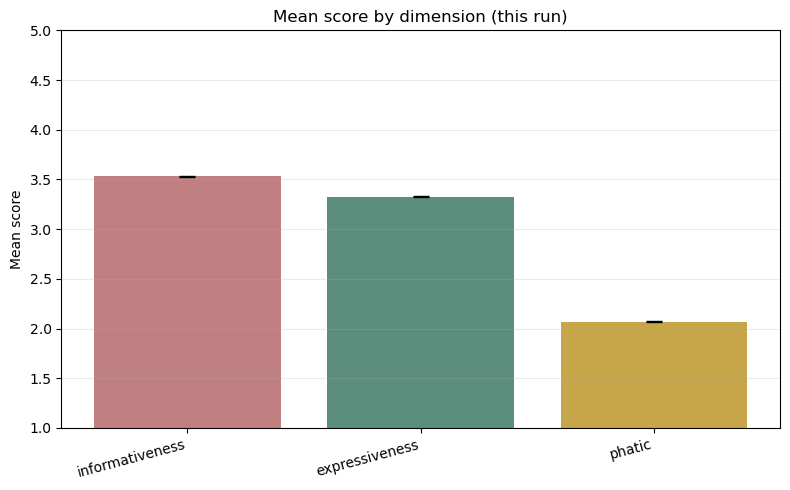

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_df = scores_df.copy()
for c in ["informativeness", "expressiveness", "phatic"]:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

dims = ["informativeness", "expressiveness", "phatic"]
means = [plot_df[c].mean() for c in dims]
stds = [plot_df[c].std() for c in dims]
ns = [plot_df[c].notna().sum() for c in dims]
sems = [s / np.sqrt(n) if n > 0 else 0 for s, n in zip(stds, ns)]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#C08081", "#5B8E7D", "#C7A64A"]
ax.bar(dims, means, yerr=sems, capsize=6, color=colors)
ax.set_ylim(1, 5)
ax.set_ylabel("Mean score")
ax.set_title("Mean score by dimension (this run)")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

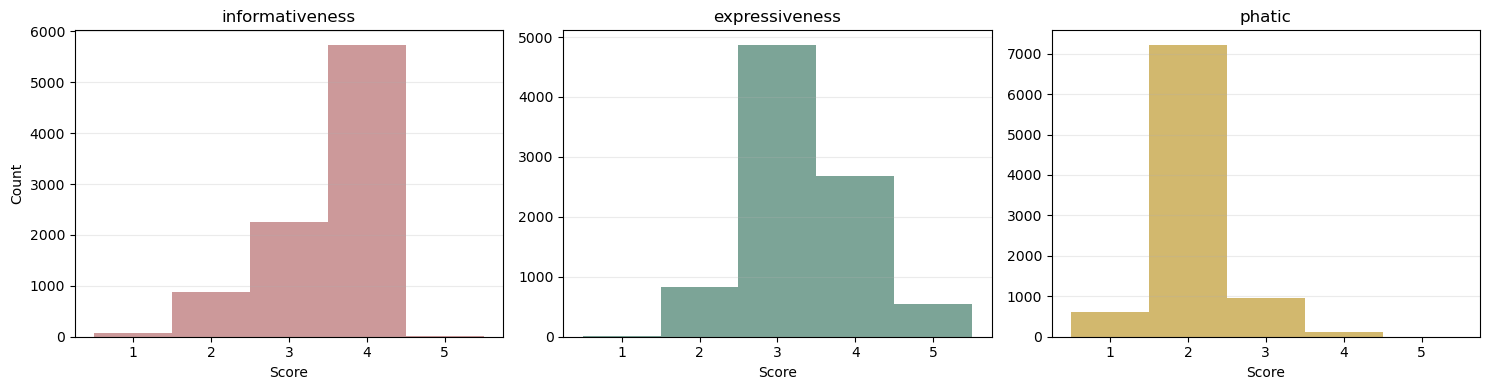

In [26]:
# Graph C: Score distributions (histograms)
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
score_cols = ["informativeness", "expressiveness", "phatic"]
colors = {"informativeness": "#C08081", "expressiveness": "#5B8E7D", "phatic": "#C7A64A"}
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]

for ax, col in zip(axes, score_cols):
    vals = pd.to_numeric(scores_df[col], errors="coerce").dropna()
    ax.hist(vals, bins=bins, color=colors[col], alpha=0.8)
    ax.set_title(col)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xlabel("Score")
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

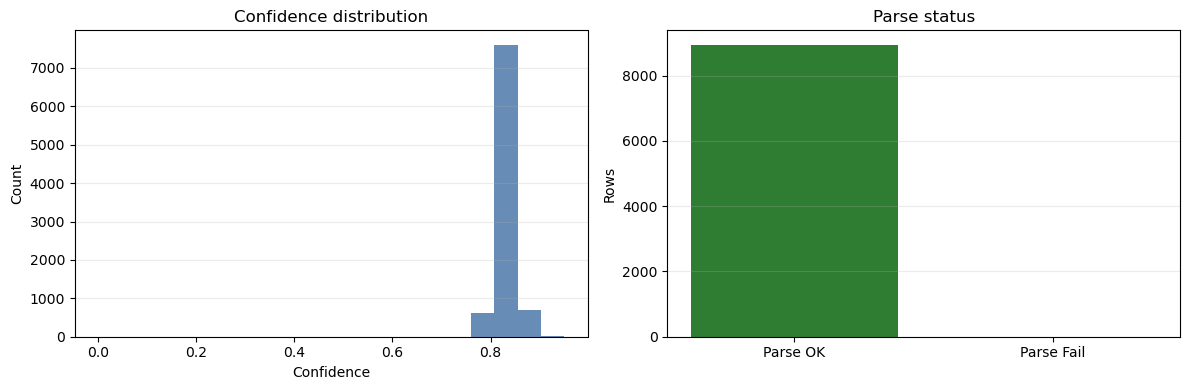

In [27]:
# Graph D: Confidence + parse quality
import pandas as pd
import matplotlib.pyplot as plt

tmp = scores_df.copy()
tmp["confidence"] = pd.to_numeric(tmp["confidence"], errors="coerce")
tmp["parse_ok"] = tmp["parse_ok"].fillna(False).astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(tmp["confidence"].dropna(), bins=20, color="#4C78A8", alpha=0.85)
axes[0].set_title("Confidence distribution")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.25)

parse_counts = tmp["parse_ok"].value_counts()
labels = ["Parse OK", "Parse Fail"]
values = [int(parse_counts.get(True, 0)), int(parse_counts.get(False, 0))]
axes[1].bar(labels, values, color=["#2E7D32", "#C62828"])
axes[1].set_title("Parse status")
axes[1].set_ylabel("Rows")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

,chunk_id,n_rows,parse_ok_rate,informativeness_mean,expressiveness_mean,phatic_mean
35,36,200,100.0,3.755000,3.610000,2.105000
36,37,200,100.0,3.725000,3.440000,2.045000
37,38,200,100.0,3.585000,3.300000,2.070000
38,39,200,100.0,3.715000,3.315000,1.995000
39,40,200,100.0,3.600000,3.415000,2.245000
40,41,200,100.0,3.695000,3.340000,2.045000
41,42,200,100.0,3.600000,3.350000,1.995000
42,43,200,100.0,3.725000,3.365000,2.090000
43,44,200,100.0,3.655000,3.415000,2.120000
44,45,138,100.0,3.608696,3.434783,2.036232


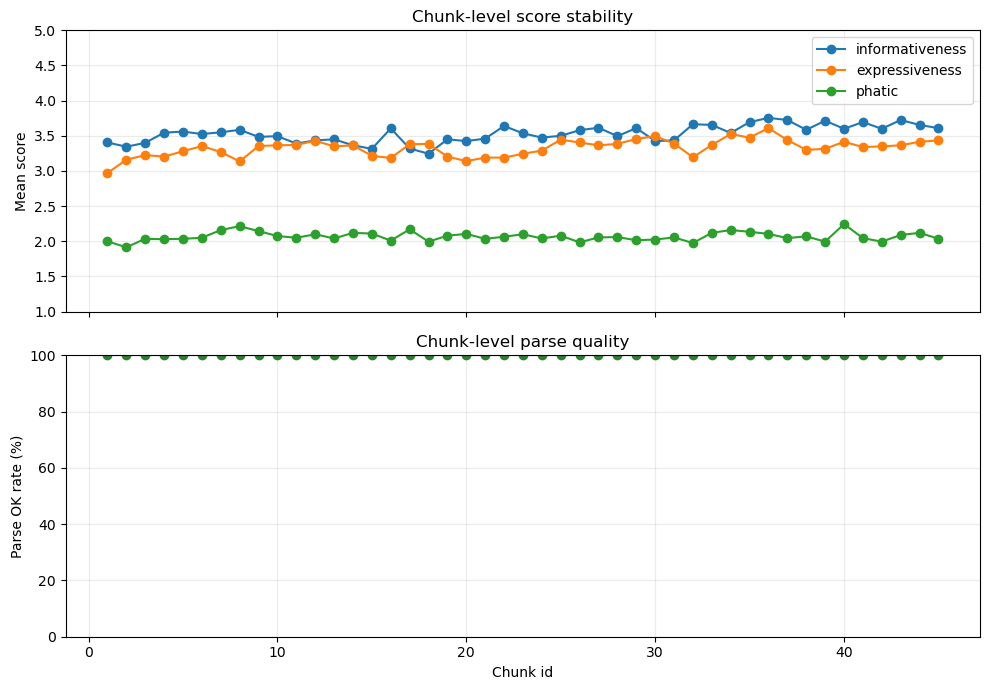

In [28]:
# Graph E: Chunk stability + parse rate trend
import pandas as pd
import matplotlib.pyplot as plt

tmp = scores_df.copy()
for c in ["informativeness", "expressiveness", "phatic"]:
    tmp[c] = pd.to_numeric(tmp[c], errors="coerce")
tmp["parse_ok"] = tmp["parse_ok"].fillna(False).astype(bool)

CHUNK_SIZE = 200
rows = []
for start in range(0, len(tmp), CHUNK_SIZE):
    chunk = tmp.iloc[start:start + CHUNK_SIZE]
    if len(chunk) == 0:
        continue
    rows.append({
        "chunk_id": len(rows) + 1,
        "n_rows": len(chunk),
        "parse_ok_rate": chunk["parse_ok"].mean() * 100,
        "informativeness_mean": chunk["informativeness"].mean(),
        "expressiveness_mean": chunk["expressiveness"].mean(),
        "phatic_mean": chunk["phatic"].mean(),
    })

chunk_df = pd.DataFrame(rows)
display(chunk_df.tail(10))

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(chunk_df["chunk_id"], chunk_df["informativeness_mean"], marker="o", label="informativeness")
axes[0].plot(chunk_df["chunk_id"], chunk_df["expressiveness_mean"], marker="o", label="expressiveness")
axes[0].plot(chunk_df["chunk_id"], chunk_df["phatic_mean"], marker="o", label="phatic")
axes[0].set_ylim(1, 5)
axes[0].set_ylabel("Mean score")
axes[0].set_title("Chunk-level score stability")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(chunk_df["chunk_id"], chunk_df["parse_ok_rate"], marker="o", color="#2E7D32")
axes[1].set_ylabel("Parse OK rate (%)")
axes[1].set_xlabel("Chunk id")
axes[1].set_ylim(0, 100)
axes[1].set_title("Chunk-level parse quality")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

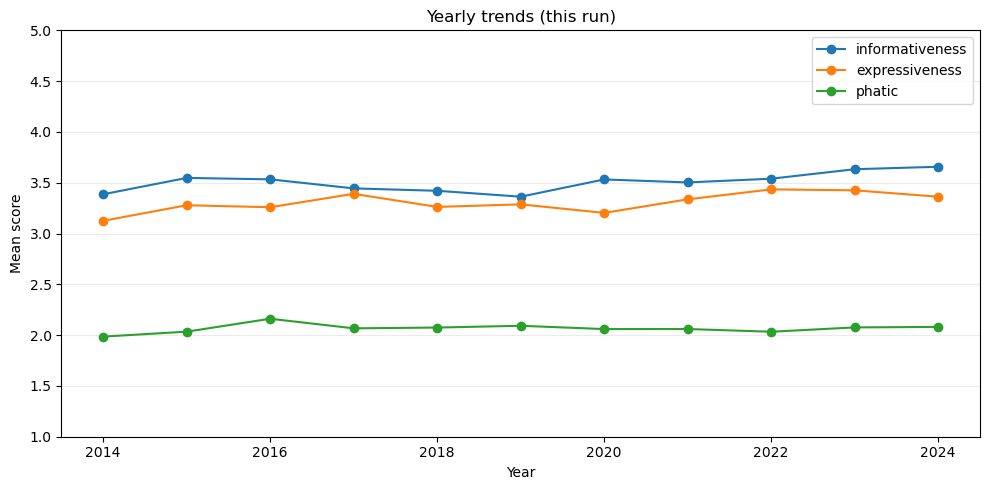

In [29]:
# Graph F: Yearly trends (single model), if year exists
import pandas as pd
import matplotlib.pyplot as plt

if "year" in df.columns:
    year_src = df[["row_id", "year"]].copy()
    year_src["year"] = pd.to_numeric(year_src["year"], errors="coerce")

    trend = scores_df.merge(year_src, on="row_id", how="left").dropna(subset=["year"]).copy()
    trend["year"] = trend["year"].astype(int)
    for c in ["informativeness", "expressiveness", "phatic"]:
        trend[c] = pd.to_numeric(trend[c], errors="coerce")

    yearly = trend.groupby("year", as_index=False)[["informativeness", "expressiveness", "phatic"]].mean()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(yearly["year"], yearly["informativeness"], marker="o", label="informativeness")
    ax.plot(yearly["year"], yearly["expressiveness"], marker="o", label="expressiveness")
    ax.plot(yearly["year"], yearly["phatic"], marker="o", label="phatic")
    ax.set_ylim(1, 5)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean score")
    ax.set_title("Yearly trends (this run)")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No year column found in df.")

score,1,2,3,4,5
dimension,,,,,
informativeness,0.820896,0.835918,0.846116,0.854501,0.922222
expressiveness,0.640000,0.844680,0.847422,0.848262,0.900996
phatic,0.846538,0.849550,0.858428,0.853488,0.900000


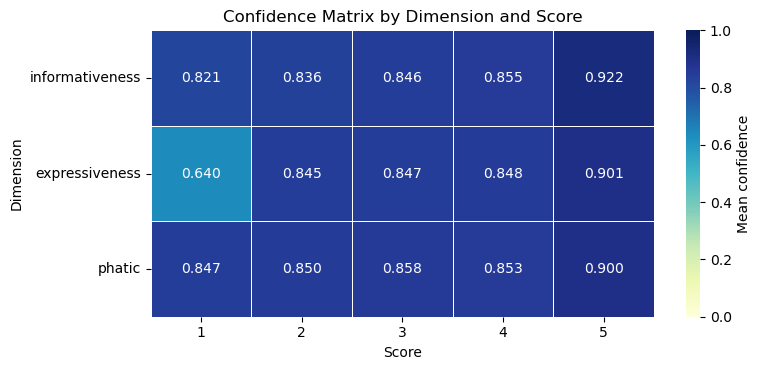

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Prepare data
cm_df = scores_df.copy()
dims = ["informativeness", "expressiveness", "phatic"]

cm_df["confidence"] = pd.to_numeric(cm_df["confidence"], errors="coerce")
for d in dims:
    cm_df[d] = pd.to_numeric(cm_df[d], errors="coerce")

# 2) Long format: one row per (row_id, dimension, score, confidence)
long_df = cm_df.melt(
    id_vars=["row_id", "confidence"],
    value_vars=dims,
    var_name="dimension",
    value_name="score"
).dropna(subset=["score", "confidence"])

long_df["score"] = long_df["score"].round().astype(int)
long_df = long_df[long_df["score"].between(1, 5)]

# 3) Confidence matrix: rows=dimension, cols=score(1..5), values=mean confidence
confidence_matrix = (
    long_df.groupby(["dimension", "score"], as_index=False)["confidence"]
    .mean()
    .pivot(index="dimension", columns="score", values="confidence")
    .reindex(index=dims, columns=[1, 2, 3, 4, 5])
)

display(confidence_matrix)

# 4) Heatmap
plt.figure(figsize=(8, 3.8))
sns.heatmap(
    confidence_matrix,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Mean confidence"}
)
plt.title("Confidence Matrix by Dimension and Score")
plt.xlabel("Score")
plt.ylabel("Dimension")
plt.tight_layout()
plt.show()

,informativeness,expressiveness,phatic
informativeness,1.000000,-0.356894,-0.090718
expressiveness,-0.356894,1.000000,0.283052
phatic,-0.090718,0.283052,1.000000


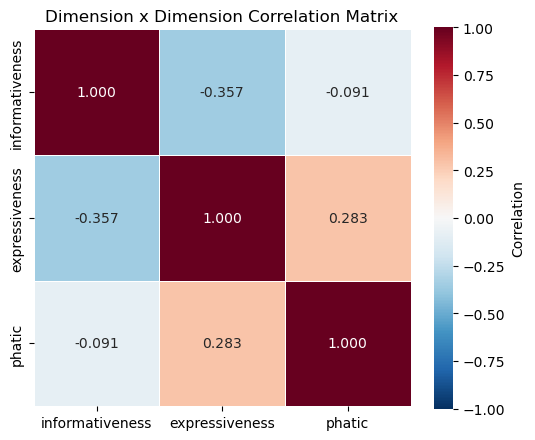

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dims = ["informativeness", "expressiveness", "phatic"]

corr_df = scores_df.copy()
for d in dims:
    corr_df[d] = pd.to_numeric(corr_df[d], errors="coerce")

matrix = corr_df[dims].corr(method="pearson")  # dimension x dimension
display(matrix)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)
plt.title("Dimension x Dimension Correlation Matrix")
plt.tight_layout()
plt.show()

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Find electrification column in df
candidate_cols = [
    "electrified", "is_electrified", "electrification",
    "electrique", "electrifie", "electrifié"
]
elec_col = next((c for c in candidate_cols if c in df.columns), None)
if elec_col is None:
    raise ValueError(f"No electrification column found. Tried: {candidate_cols}")

# 2) Merge scores with electrification info
plot_df = scores_df.merge(df[["row_id", elec_col]], on="row_id", how="left").copy()

# 3) Normalize labels to two groups
def to_group(v):
    t = str(v).strip().lower()
    if t in {"1", "true", "yes", "y", "electrified", "électrifié", "electrifie", "ev", "phev", "hybrid", "hybride"}:
        return "electrified"
    if t in {"0", "false", "no", "n", "non_electrified", "non-electrified", "thermique", "ice"}:
        return "non_electrified"
    return np.nan

plot_df["powertrain_group"] = plot_df[elec_col].apply(to_group)
plot_df = plot_df.dropna(subset=["powertrain_group"])

dims = ["informativeness", "expressiveness", "phatic"]
for d in dims:
    plot_df[d] = pd.to_numeric(plot_df[d], errors="coerce")

# 4) Mean by group
mean_by_group = (
    plot_df.groupby("powertrain_group", as_index=False)[dims]
    .mean()
    .set_index("powertrain_group")
    .reindex(["electrified", "non_electrified"])
)

display(mean_by_group)

# 5) Vertical grouped bars
x = np.arange(len(dims))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    x - width/2,
    mean_by_group.loc["electrified", dims].values,
    width,
    label="electrified",
    color="#2E7D32"
)
ax.bar(
    x + width/2,
    mean_by_group.loc["non_electrified", dims].values,
    width,
    label="non_electrified",
    color="#546E7A"
)

ax.set_xticks(x)
ax.set_xticklabels(dims, rotation=15, ha="right")
ax.set_ylim(1, 5)
ax.set_ylabel("Mean score")
ax.set_title("Scores by Electrified vs Non-Electrified")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

ValueError: No electrification column found. Tried: ['electrified', 'is_electrified', 'electrification', 'electrique', 'electrifie', 'electrifié']

## 16) Multi-model comparison setup

In [16]:
# This cell scans existing score CSVs so you can compare multiple model runs together.
score_files = sorted(OUTPUT_ROOT.parent.rglob("*_scores.csv"))
comparison_frames = []
for path in score_files:
    try:
        tmp = pd.read_csv(path)
        if {"row_id", "informativeness", "expressiveness", "phatic", "model_name"}.issubset(tmp.columns):
            tmp["source_file"] = str(path)
            comparison_frames.append(tmp)
    except Exception:
        pass

if not comparison_frames:
    raise RuntimeError("No score CSVs found for model comparison.")

comparison_df = pd.concat(comparison_frames, ignore_index=True)
comparison_df["model_display"] = comparison_df["model_name"].fillna("unknown_model")
for col in ["informativeness", "expressiveness", "phatic"]:
    comparison_df[col] = pd.to_numeric(comparison_df[col], errors="coerce")

display(comparison_df[["model_display", "row_id", "informativeness", "expressiveness", "phatic"]].head(10))
print("Models found:", sorted(comparison_df["model_display"].dropna().unique().tolist()))


,model_display,row_id,informativeness,expressiveness,phatic
0,google/gemma-4-26B-A4B,0,1.0,5.0,1.0
1,google/gemma-4-26B-A4B,1,3.0,4.0,2.0
2,google/gemma-4-26B-A4B,2,1.0,5.0,1.0
3,google/gemma-4-26B-A4B,3,1.0,5.0,1.0
4,google/gemma-4-26B-A4B,4,1.0,5.0,1.0
5,google/gemma-4-26B-A4B,5,4.0,2.0,1.0
6,google/gemma-4-26B-A4B,6,1.0,5.0,1.0
7,google/gemma-4-26B-A4B,7,1.0,5.0,1.0
8,google/gemma-4-26B-A4B,8,1.0,5.0,1.0
9,google/gemma-4-26B-A4B,9,1.0,5.0,1.0


Models found: ['Qwen/Qwen2.5-32B-Instruct', 'Qwen/Qwen2.5-72B-Instruct', 'google/gemma-4-26B-A4B', 'meta-llama/Llama-3.3-70B-Instruct', 'mistralai/Mixtral-8x22B-Instruct-v0.1']


## 17) Graph 1: mean score comparison by model

,model_display,informativeness,expressiveness,phatic
0,Qwen/Qwen2.5-32B-Instruct,2.053144,3.839785,2.330387
1,Qwen/Qwen2.5-72B-Instruct,2.753171,3.345127,2.069482
2,google/gemma-4-26B-A4B,1.933430,4.234169,1.433318
3,meta-llama/Llama-3.3-70B-Instruct,NaN,NaN,NaN
4,mistralai/Mixtral-8x22B-Instruct-v0.1,NaN,NaN,NaN


Saved: /home/cbenavent/test/Arcom_rares/latex/means_by_model.png


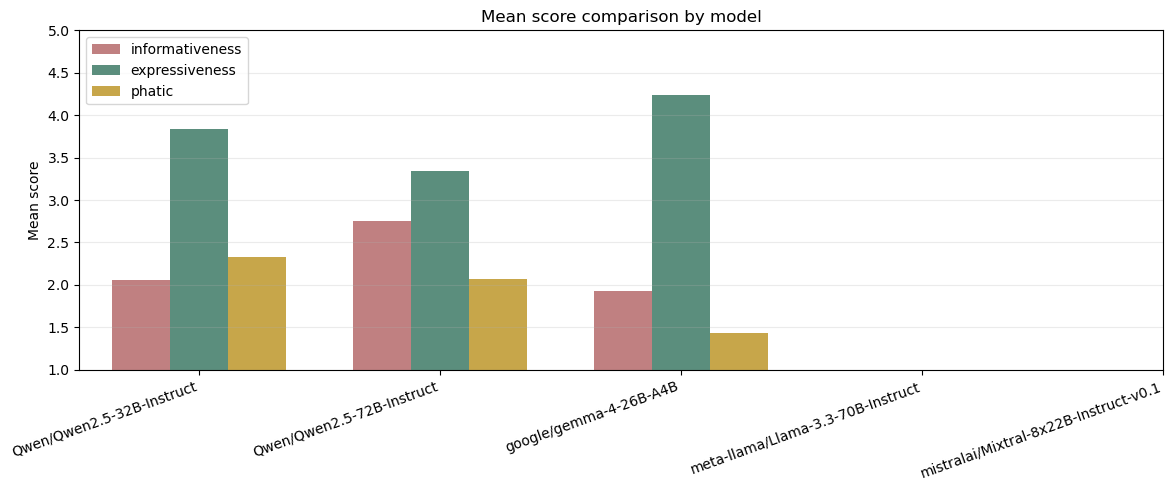

In [17]:
mean_by_model = comparison_df.groupby("model_display", as_index=False)[["informativeness", "expressiveness", "phatic"]].mean()
display(mean_by_model)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(mean_by_model))
width = 0.24
ax.bar(x - width, mean_by_model["informativeness"], width, label="informativeness", color="#C08081")
ax.bar(x, mean_by_model["expressiveness"], width, label="expressiveness", color="#5B8E7D")
ax.bar(x + width, mean_by_model["phatic"], width, label="phatic", color="#C7A64A")
ax.set_xticks(x)
ax.set_xticklabels(mean_by_model["model_display"], rotation=20, ha="right")
ax.set_ylim(1, 5)
ax.set_ylabel("Mean score")
ax.set_title("Mean score comparison by model")
ax.legend()
ax.grid(axis="y", alpha=0.25)
means_plot_path = LATEX_DIR / "means_by_model.png"
fig.savefig(means_plot_path, dpi=200, bbox_inches="tight")
print("Saved:", means_plot_path)
plt.tight_layout()
plt.show()


## 18) Graph 2: dominant-dimension shares by model

,model_display,dominant_dimension,n,share_percent
0,Qwen/Qwen2.5-72B-Instruct,expressiveness,3279,36.686060
1,Qwen/Qwen2.5-72B-Instruct,informativeness,5299,59.286194
2,Qwen/Qwen2.5-72B-Instruct,mixed,282,3.155068
3,Qwen/Qwen2.5-72B-Instruct,phatic,78,0.872678


Saved: /home/cbenavent/test/Arcom_rares/latex/dominant_dimension_share_by_model.png


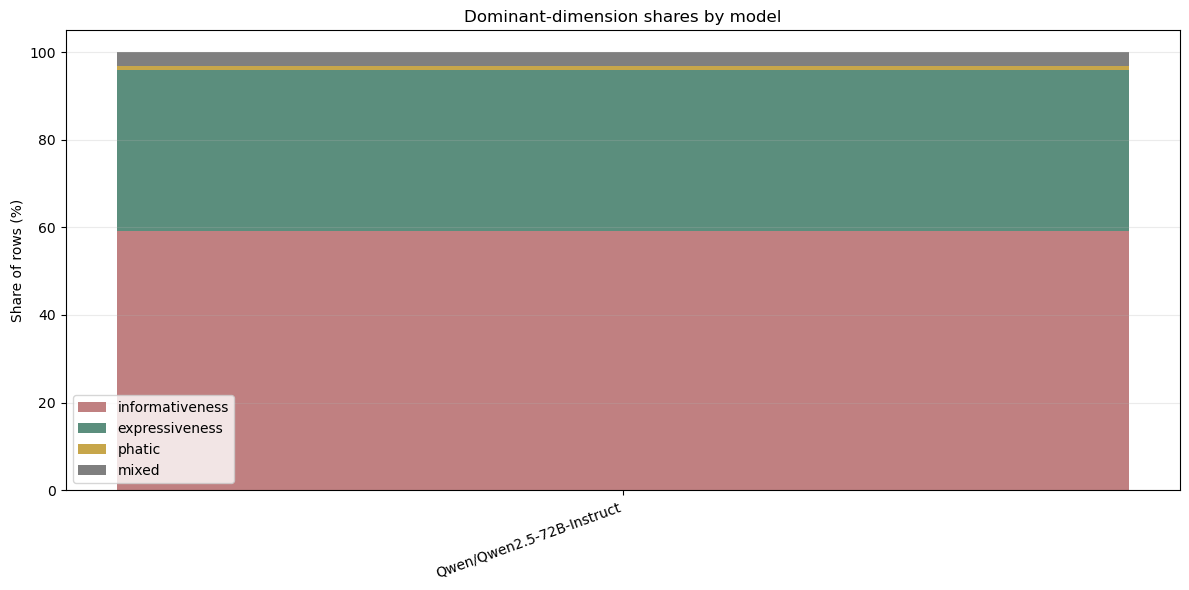

In [18]:
dom_share = (
    comparison_df.groupby(["model_display", "dominant_dimension"])
    .size()
    .rename("n")
    .reset_index()
)
totals = dom_share.groupby("model_display")["n"].transform("sum")
dom_share["share_percent"] = dom_share["n"] / totals * 100
display(dom_share.head(20))

pivot_dom = dom_share.pivot(index="model_display", columns="dominant_dimension", values="share_percent").fillna(0)
fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(pivot_dom))
colors = {"informativeness": "#C08081", "expressiveness": "#5B8E7D", "phatic": "#C7A64A", "mixed": "#7F7F7F"}
for col in ["informativeness", "expressiveness", "phatic", "mixed"]:
    if col in pivot_dom.columns:
        ax.bar(pivot_dom.index, pivot_dom[col], bottom=bottom, label=col, color=colors[col])
        bottom += pivot_dom[col].values
ax.set_ylabel("Share of rows (%)")
ax.set_title("Dominant-dimension shares by model")
ax.legend()
ax.grid(axis="y", alpha=0.25)
dom_plot_path = LATEX_DIR / "dominant_dimension_share_by_model.png"
fig.savefig(dom_plot_path, dpi=200, bbox_inches="tight")
print("Saved:", dom_plot_path)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 19) Graph 3: score distribution histograms by model

Saved: /home/cbenavent/test/Arcom_rares/latex/score_distributions_by_model.png


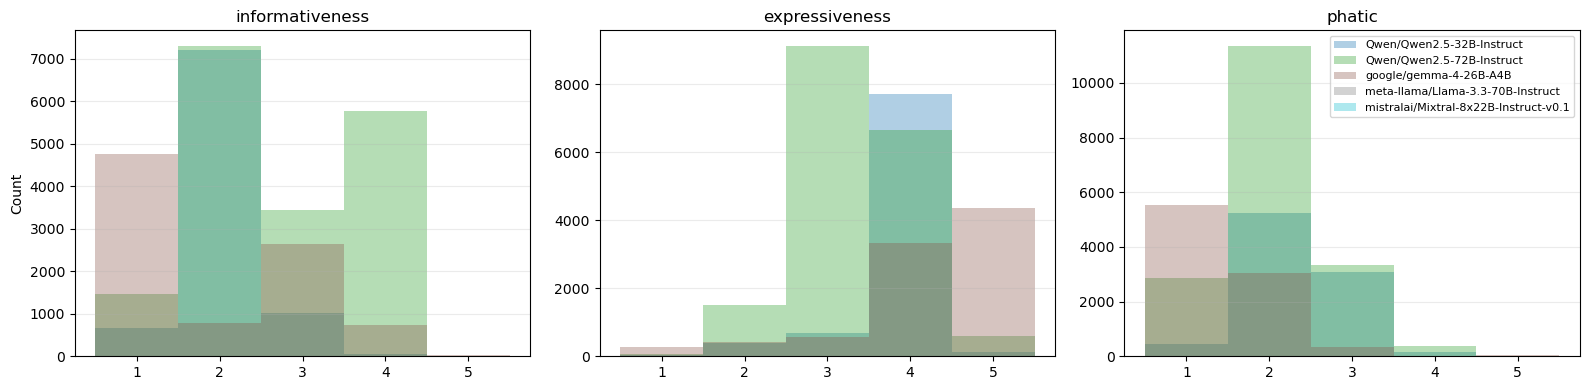

In [19]:
models = sorted(comparison_df["model_display"].dropna().unique().tolist())
score_cols = ["informativeness", "expressiveness", "phatic"]
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
palette = plt.cm.tab10(np.linspace(0, 1, max(3, len(models))))

for ax, col in zip(axes, score_cols):
    for model, color in zip(models, palette):
        vals = comparison_df.loc[comparison_df["model_display"] == model, col].dropna()
        ax.hist(vals, bins=bins, alpha=0.35, label=model, color=color)
    ax.set_title(col)
    ax.set_xticks([1,2,3,4,5])
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Count")
axes[-1].legend(fontsize=8)
dist_plot_path = LATEX_DIR / "score_distributions_by_model.png"
fig.savefig(dist_plot_path, dpi=200, bbox_inches="tight")
print("Saved:", dist_plot_path)
plt.tight_layout()
plt.show()


## 20) Graph 4: exact agreement and within-1-point agreement

,pair,dimension,exact_agreement,within1_agreement
0,Qwen/Qwen2.5-32B-Instruct vs Qwen/Qwen2.5-72B-...,informativeness,47.746996,71.523142
1,Qwen/Qwen2.5-32B-Instruct vs Qwen/Qwen2.5-72B-...,expressiveness,42.606809,94.909880
2,Qwen/Qwen2.5-32B-Instruct vs Qwen/Qwen2.5-72B-...,phatic,54.194482,98.297730
3,Qwen/Qwen2.5-32B-Instruct vs google/gemma-4-26...,informativeness,20.698143,96.554039
4,Qwen/Qwen2.5-32B-Instruct vs google/gemma-4-26...,expressiveness,36.216156,93.499664
5,Qwen/Qwen2.5-32B-Instruct vs google/gemma-4-26...,phatic,30.118595,75.363616
6,Qwen/Qwen2.5-32B-Instruct vs meta-llama/Llama-...,informativeness,0.000000,0.000000
7,Qwen/Qwen2.5-32B-Instruct vs meta-llama/Llama-...,expressiveness,0.000000,0.000000
8,Qwen/Qwen2.5-32B-Instruct vs meta-llama/Llama-...,phatic,0.000000,0.000000
9,Qwen/Qwen2.5-32B-Instruct vs mistralai/Mixtral...,informativeness,0.000000,0.000000


Saved: /home/cbenavent/test/Arcom_rares/latex/agreement_exact_within1_by_dimension.png


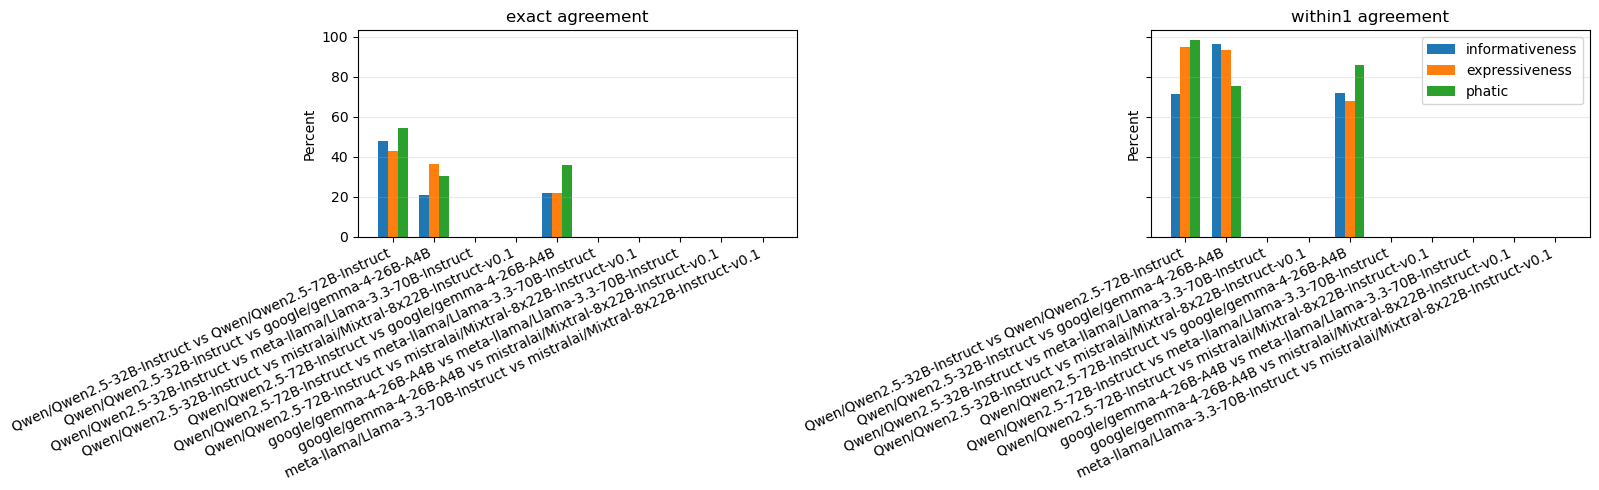

In [20]:
from itertools import combinations

rows = []
for model_a, model_b in combinations(sorted(comparison_df["model_display"].dropna().unique()), 2):
    left = comparison_df[comparison_df["model_display"] == model_a][["row_id", "informativeness", "expressiveness", "phatic"]].copy()
    right = comparison_df[comparison_df["model_display"] == model_b][["row_id", "informativeness", "expressiveness", "phatic"]].copy()
    merged = left.merge(right, on="row_id", suffixes=("_a", "_b"))
    if merged.empty:
        continue
    for col in ["informativeness", "expressiveness", "phatic"]:
        exact = (merged[f"{col}_a"] == merged[f"{col}_b"]).mean() * 100
        within1 = ((merged[f"{col}_a"] - merged[f"{col}_b"]).abs() <= 1).mean() * 100
        rows.append({
            "pair": f"{model_a} vs {model_b}",
            "dimension": col,
            "exact_agreement": exact,
            "within1_agreement": within1,
        })

agreement_df = pd.DataFrame(rows)
display(agreement_df.head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, metric in zip(axes, ["exact_agreement", "within1_agreement"]):
    pivot = agreement_df.pivot(index="pair", columns="dimension", values=metric)
    x = np.arange(len(pivot))
    width = 0.24
    for idx, dim in enumerate(["informativeness", "expressiveness", "phatic"]):
        ax.bar(x + (idx-1)*width, pivot[dim], width, label=dim)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=25, ha="right")
    ax.set_title(metric.replace("_", " "))
    ax.set_ylabel("Percent")
    ax.grid(axis="y", alpha=0.25)
axes[1].legend()
agreement_plot_path = LATEX_DIR / "agreement_exact_within1_by_dimension.png"
fig.savefig(agreement_plot_path, dpi=200, bbox_inches="tight")
print("Saved:", agreement_plot_path)
plt.tight_layout()
plt.show()


## 21) Graph 5: expressiveness pair heatmap

Saved: /home/cbenavent/test/Arcom_rares/latex/expressiveness_pair_heatmap.png


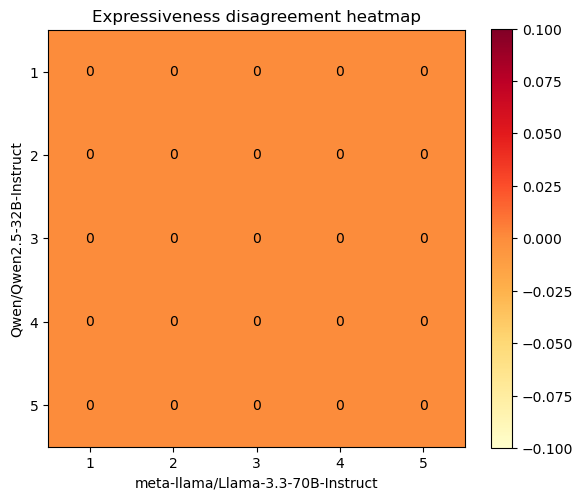

In [21]:
from itertools import combinations

pairs = []
for model_a, model_b in combinations(sorted(comparison_df["model_display"].dropna().unique()), 2):
    left = comparison_df[comparison_df["model_display"] == model_a][["row_id", "expressiveness"]].copy()
    right = comparison_df[comparison_df["model_display"] == model_b][["row_id", "expressiveness"]].copy()
    merged = left.merge(right, on="row_id", suffixes=("_a", "_b"))
    if merged.empty:
        continue
    exact = (merged["expressiveness_a"] == merged["expressiveness_b"]).mean()
    pairs.append((model_a, model_b, exact))

if not pairs:
    raise RuntimeError("Need at least two model outputs with overlapping row_id values.")

worst_pair = sorted(pairs, key=lambda x: x[2])[0]
model_a, model_b, _ = worst_pair
left = comparison_df[comparison_df["model_display"] == model_a][["row_id", "expressiveness"]].copy()
right = comparison_df[comparison_df["model_display"] == model_b][["row_id", "expressiveness"]].copy()
merged = left.merge(right, on="row_id", suffixes=("_a", "_b"))
heat = pd.crosstab(merged["expressiveness_a"], merged["expressiveness_b"]).reindex(index=[1,2,3,4,5], columns=[1,2,3,4,5], fill_value=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(heat.values, cmap="YlOrRd")
fig.colorbar(im, ax=ax)
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels([1,2,3,4,5])
ax.set_yticklabels([1,2,3,4,5])
ax.set_xlabel(model_b)
ax.set_ylabel(model_a)
ax.set_title("Expressiveness disagreement heatmap")
for i in range(5):
    for j in range(5):
        ax.text(j, i, str(int(heat.values[i, j])), ha="center", va="center", color="black")
heatmap_path = LATEX_DIR / "expressiveness_pair_heatmap.png"
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
print("Saved:", heatmap_path)
plt.tight_layout()
plt.show()


## 22) Graph 6: yearly trends by model

Saved: /home/cbenavent/test/Arcom_rares/latex/yearly_trends_by_model.png


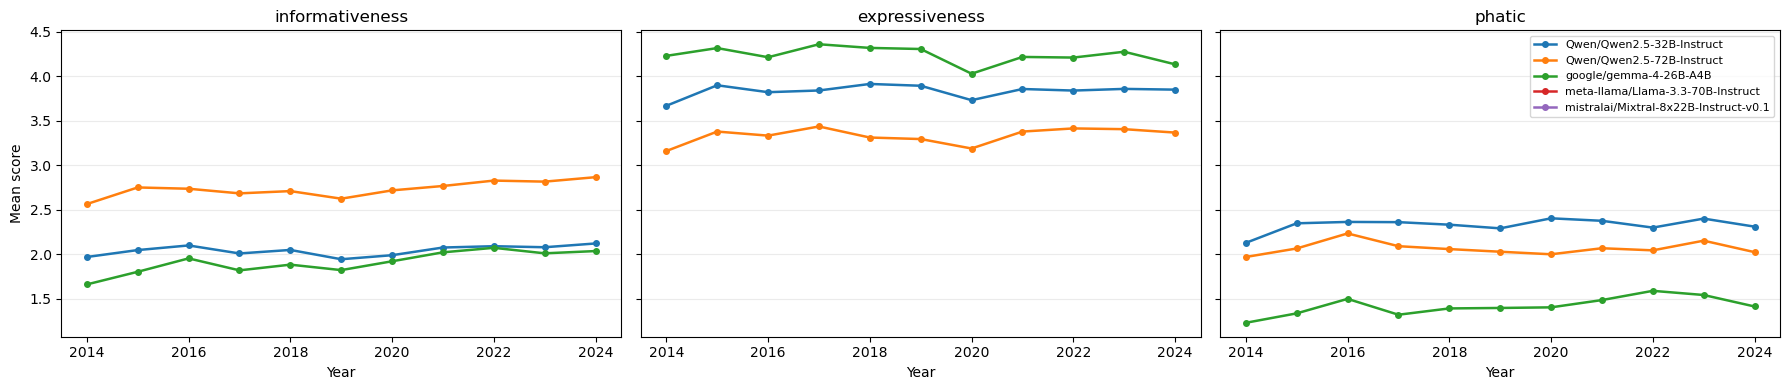

In [22]:
year_source = df.loc[:, ["row_id", "year"]].copy()
year_source["year"] = pd.to_numeric(year_source["year"], errors="coerce")
trend_df = comparison_df.merge(year_source, on="row_id", how="left").dropna(subset=["year"]).copy()
trend_df["year"] = trend_df["year"].astype(int)

score_cols = ["informativeness", "expressiveness", "phatic"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, col in zip(axes, score_cols):
    grouped = trend_df.groupby(["model_display", "year"], as_index=False)[col].mean()
    for model in sorted(grouped["model_display"].unique()):
        tmp = grouped[grouped["model_display"] == model]
        ax.plot(tmp["year"], tmp[col], marker="o", linewidth=1.8, markersize=4, label=model)
    ax.set_title(col)
    ax.set_xlabel("Year")
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Mean score")
axes[-1].legend(fontsize=8)
yearly_plot_path = LATEX_DIR / "yearly_trends_by_model.png"
fig.savefig(yearly_plot_path, dpi=200, bbox_inches="tight")
print("Saved:", yearly_plot_path)
plt.tight_layout()
plt.show()
